<a href="https://colab.research.google.com/github/gre1wy/Machine_Learning/blob/main/lab2b_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


https://elcaiseri.medium.com/building-a-multi-layer-perceptron-from-scratch-with-numpy-e4cee82ab06d  
https://medium.com/data-science/derivative-of-the-softmax-function-and-the-categorical-cross-entropy-loss-ffceefc081d1

In [77]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

class MLPFromScratch:

    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def _relu(self, Z):
        return np.maximum(0, Z)

    def _relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def _softmax(self, Z):
        expZ = np.exp(Z - np.max(Z))
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    def forward(self, X):

        Z1 = X.dot(self.W1) + self.b1
        A1 = self._relu(Z1)
        Z2 = A1.dot(self.W2) + self.b2
        A2 = self._softmax(Z2)
        return Z1, A1, Z2, A2

    def _compute_loss(self, Y_onehot, A2):
        m = Y_onehot.shape[0]
        correct_logprobs = -np.log(A2[range(m), np.argmax(Y_onehot, axis=1)] + 1e-9)
        return np.mean(correct_logprobs)

    def backward(self, X, Y_onehot, Z1, A1, Z2, A2):
        m = X.shape[0]

        dL_dZ2 = A2 - Y_onehot
        dL_dW2 = (A1.T @ dL_dZ2) / m
        dL_db2 = np.sum(dL_dZ2, axis=0, keepdims=True) / m

        dL_dA1 = dL_dZ2 @ self.W2.T
        dA_dZ1 = dL_dA1 * self._relu_derivative(Z1)
        dL_dW1 = (X.T @ dA_dZ1) / m
        dL_db1 = np.sum(dA_dZ1, axis=0, keepdims=True) / m

        return dL_dW1, dL_db1, dL_dW2, dL_db2

    def update_params(self, dW1, db1, dW2, db2, learning_rate):
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

    def fit(self, X, y, epochs=1000, learning_rate=0.01):
        encoder = OneHotEncoder(sparse_output=False)
        Y_onehot = encoder.fit_transform(y.reshape(-1, 1))

        history = []
        for epoch in range(epochs):
            Z1, A1, Z2, A2 = self.forward(X)

            loss = self._compute_loss(Y_onehot, A2)
            history.append(loss)

            dW1, db1, dW2, db2 = self.backward(X, Y_onehot, Z1, A1, Z2, A2)

            self.update_params(dW1, db1, dW2, db2, learning_rate)

            if epoch % 100 == 0:
                print(f"Эпоха {epoch:4d} | Потери: {loss:.4f}")

        return history

    def predict(self, X):
        _, _, _, A2 = self.forward(X)
        return np.argmax(A2, axis=1)


$ L = -\sum_{k=1}^{K} y_k \log(s_k)$  
$s_i = \frac{e^{z_i}}{\sum_{j=1}^{K}e^{z_j}}$  



For output layer:  
$\frac{\partial L}{\partial W_2} $ - ? $\frac{\partial L}{\partial b_2} $ - ?  
$Z_2 = A_1 \cdot W_2 + b_2$  
$\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial W_2}$  
$dZ2 = \frac{\partial L}{\partial Z_2} = S - Y$, where S is the softmax output (predicted probabilities) and Y is the one-hot encoded true label vector ([Source](https://medium.com/data-science/derivative-of-the-softmax-function-and-the-categorical-cross-entropy-loss-ffceefc081d1))   
Then $\frac{\partial L}{\partial W_2} = A_1^T \cdot (S - Y)$  
$\frac{\partial L}{\partial b_2} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial b_2} =  \sum_{i=1}^{m} (S-Y)_i$

For hidden layer:  
$\frac{\partial L}{\partial W_1} $ - ? $\frac{\partial L}{\partial b_1} $ - ?   
$Z_1 = X \cdot W1 + b_1$ , $A_1$ = relu($Z_1$)  
$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1} \cdot \frac{\partial Z_1}{\partial W_1} = dZ1 \cdot \frac{\partial Z_1}{\partial W_1}$  
1. $\frac{\partial L}{\partial A_1} = \frac{\partial L}{\partial Z_2} \cdot \frac{\partial Z_2}{\partial A_1}$  
$\frac{\partial L}{\partial Z_2} = S - Y$  
$\frac{\partial Z_2}{\partial A_1} = W_2^T$  
2. $\frac{\partial A_1}{\partial Z_1} = [Z_1>0]$
3. $\frac{\partial Z_1}{\partial W_1} = X^T$  

Then $\frac{\partial L}{\partial W_1} = X^T \cdot ((S - Y) \cdot W_2^T * [Z_1>0])  $ = $X^T \cdot dZ1$

$\frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial A_1} \cdot \frac{\partial A_1}{\partial Z_1} \cdot \frac{\partial Z_1}{\partial b_1} = \sum_{i=1}^{m}((S - Y) \cdot W_2^T * [Z_1>0])_i$

In [78]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
# from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [79]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Датасет: https://www.kaggle.com/datasets/rabieelkharoua/predicting-manufacturing-defects-dataset/data

In [80]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/predicting-manufacturing-defects-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'predicting-manufacturing-defects-dataset' dataset.
Path to dataset files: /kaggle/input/predicting-manufacturing-defects-dataset


In [81]:
csv_file = os.path.join(path, "manufacturing_defect_dataset.csv")
df = pd.read_csv(csv_file)

## Первинний огляд даних

In [82]:
df

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3235,762,11325.689263,89.252385,2,2.667570,87.141681,16,0.987719,3.574419,0.065727,95.917264,3,3288.043242,0.420186,4.733399,299.829577,0
3236,335,5598.837988,95.701437,4,0.751272,95.562997,11,0.178163,8.295295,0.097698,87.780846,8,2761.301593,0.126441,7.234421,245.524560,0
3237,835,11736.177712,96.431554,5,4.899756,77.973442,0,4.873429,3.844824,0.005724,81.590143,5,2000.621648,0.325530,5.436538,206.490010,1
3238,302,13664.196210,91.089782,1,4.057665,95.755591,6,0.071663,2.783298,0.042612,88.488525,6,1534.792169,0.222736,3.776924,203.771655,0


## Інформація про DataFrame

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost 

## Статистичний опис числових даних

In [84]:
df.describe()

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
count,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000
mean,548.523148,12423.018476,89.833290,2.558951,2.749116,80.134272,11.476543,2.501373,6.019662,0.050878,90.040115,4.591667,2988.494453,0.299776,5.472098,299.515479,0.840432
std,262.402073,4308.051904,5.759143,1.705804,1.310154,11.611750,6.872684,1.443684,2.329791,0.028797,5.723600,2.896313,1153.420820,0.116400,2.598212,116.379905,0.366261
min,100.000000,5000.174521,80.004820,0.000000,0.500710,60.010098,0.000000,0.001665,2.001611,0.000002,80.004960,0.000000,1000.720156,0.100238,1.000151,100.211137,0.000000
25%,322.000000,8728.829280,84.869219,1.000000,1.598033,70.103420,5.750000,1.264597,3.983249,0.026200,85.180203,2.000000,1988.140273,0.200502,3.228507,194.922058,1.000000
50%,549.000000,12405.204656,89.704861,3.000000,2.708775,80.265312,12.000000,2.465151,6.022389,0.051837,90.125743,5.000000,2996.822301,0.297470,5.437134,299.728918,1.000000
75%,775.250000,16124.462428,94.789936,4.000000,3.904533,90.353822,17.000000,3.774861,8.050222,0.075473,95.050838,7.000000,3984.788299,0.402659,7.741006,403.178283,1.000000
max,999.000000,19993.365549,99.989214,5.000000,4.998529,99.996993,23.000000,4.997591,9.998577,0.099997,99.996786,9.000000,4997.074741,0.499500,9.999749,499.982782,1.000000


## Кількість дублікатів у даних

In [85]:
df.duplicated().sum()

np.int64(0)

## Визначення вхідних та вихідних параметрів

In [86]:
target_variable = 'DefectStatus'
input_variables = df.columns.drop(target_variable)

## Аналіз цільової змінної

/tmp/ipython-input-3552609868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_variable, data=df, palette='pastel')


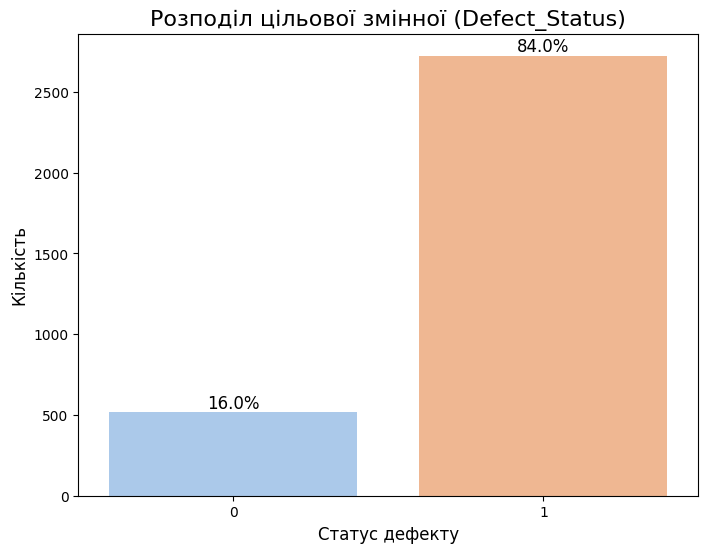

In [87]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x=target_variable, data=df, palette='pastel')
plt.title('Розподіл цільової змінної (Defect_Status)', fontsize=16)
plt.xlabel('Статус дефекту', fontsize=12)
plt.ylabel('Кількість', fontsize=12)
total = len(df[target_variable])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

plt.show()

Бачимо значний дисбаланс класів. Недефектних зразків набагато більше.

## Аналіз розподілу вхідних параметрів

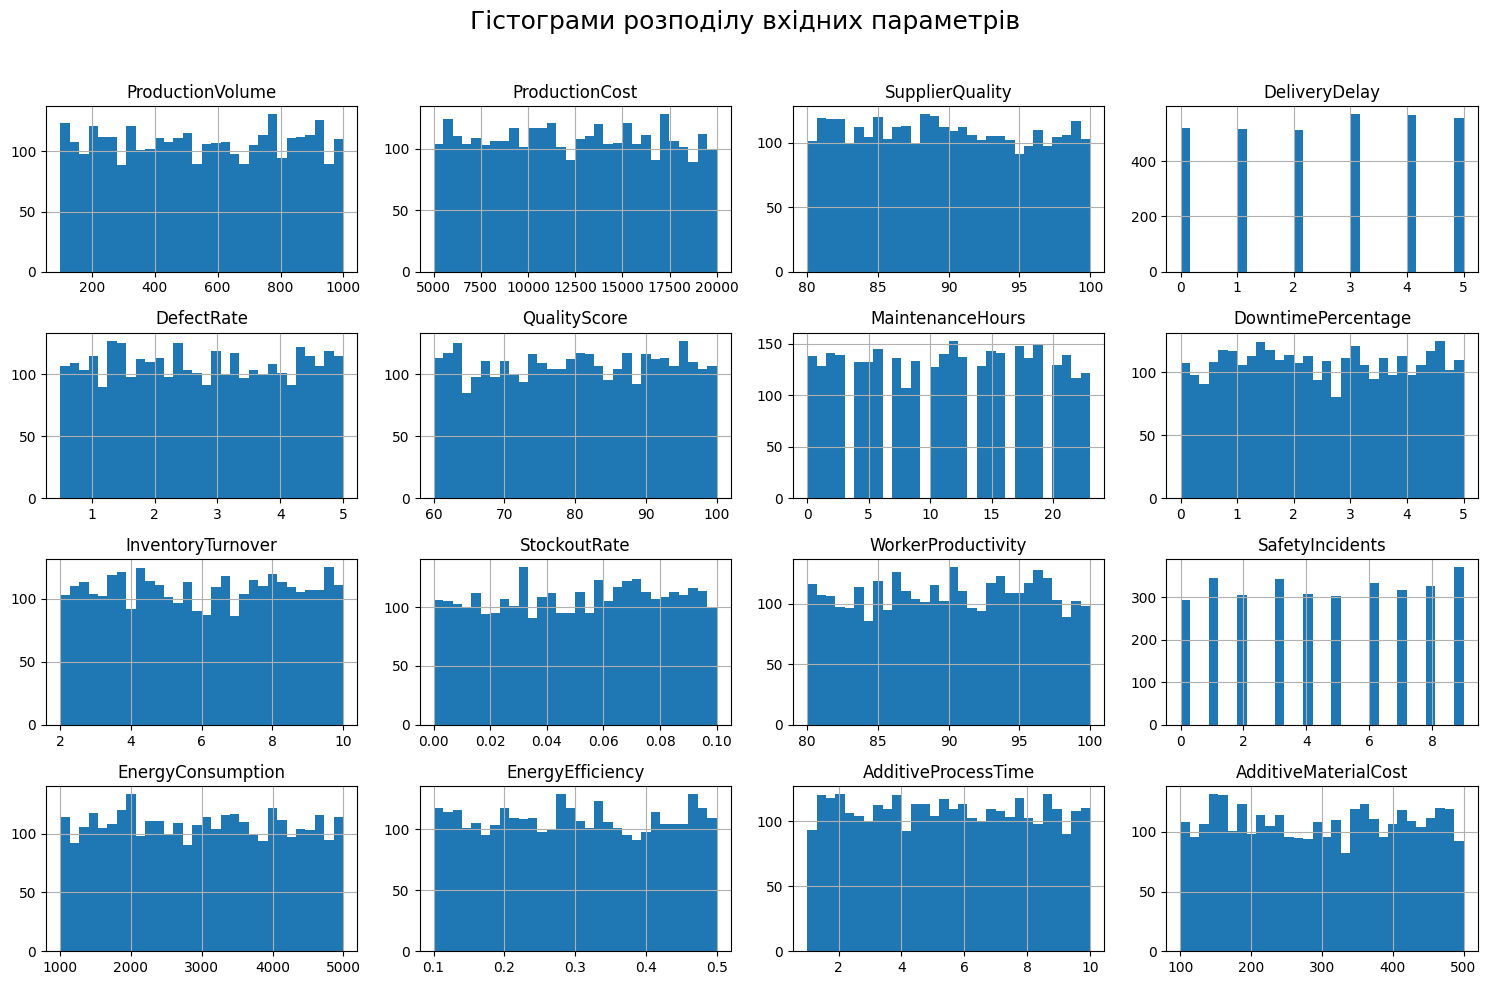

In [88]:
df[input_variables].hist(bins=30, figsize=(15, 10), layout=(4, 4))
plt.suptitle('Гістограми розподілу вхідних параметрів', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Аналіз залежностей

Візуалізація залежностей для: ['DefectRate', 'QualityScore', 'MaintenanceHours', 'ProductionCost']


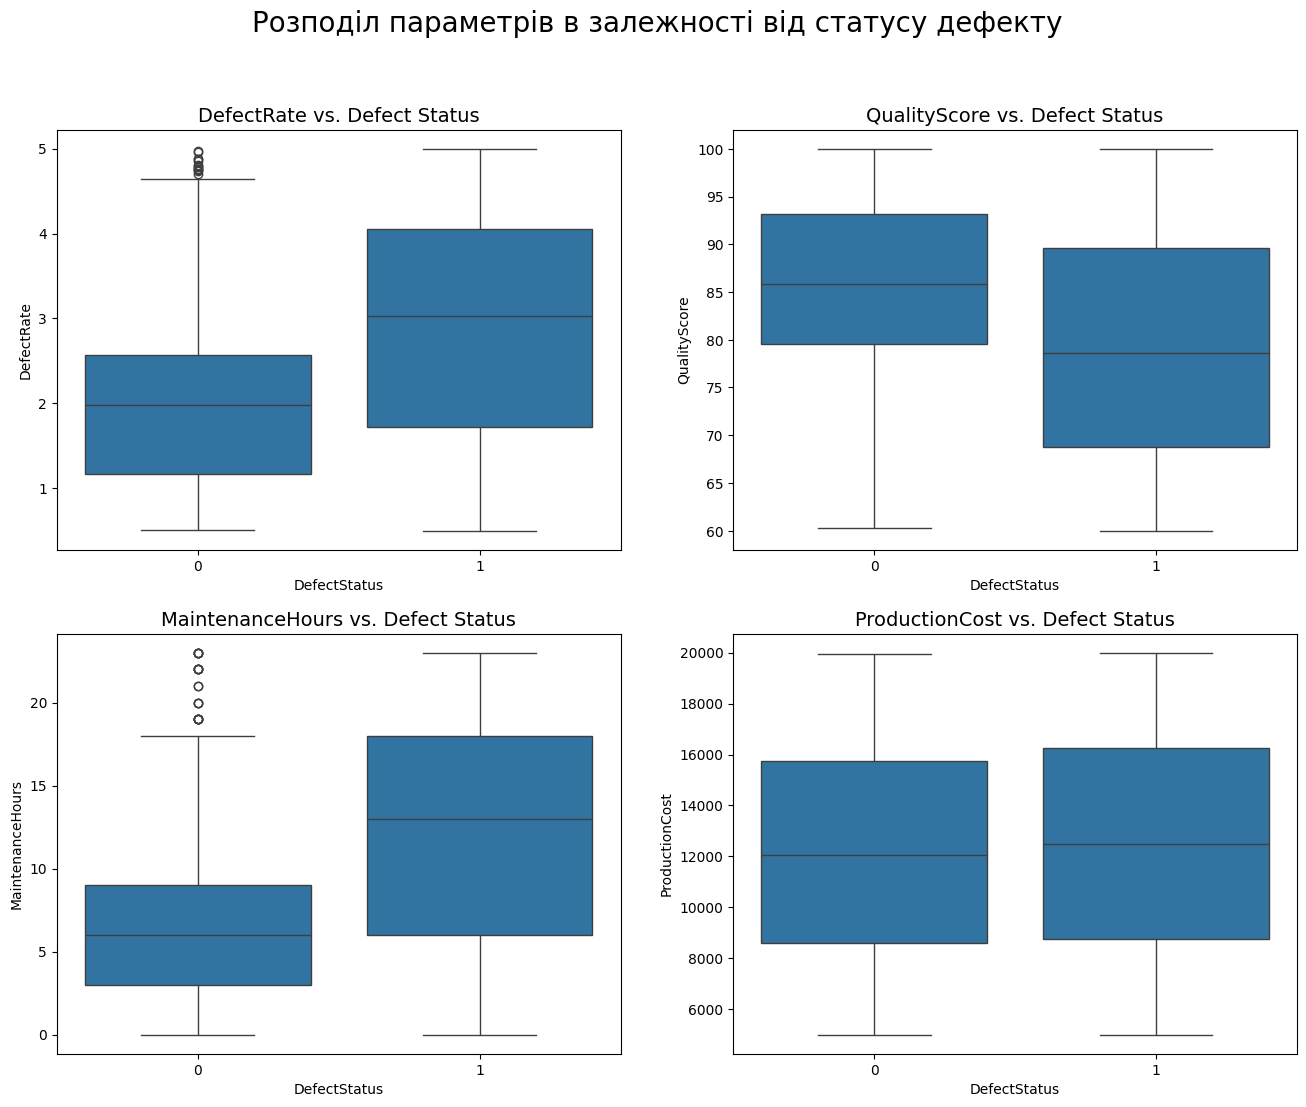

In [89]:
features_to_plot = ['DefectRate', 'QualityScore', 'MaintenanceHours', 'ProductionCost']
print(f"Візуалізація залежностей для: {features_to_plot}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Розподіл параметрів в залежності від статусу дефекту', fontsize=20)

for i, feature in enumerate(features_to_plot):
    row, col = i // 2, i % 2
    sns.boxplot(x=target_variable, y=feature, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs. Defect Status', fontsize=14)

plt.show()

## Кореляція між вхідними параметрами

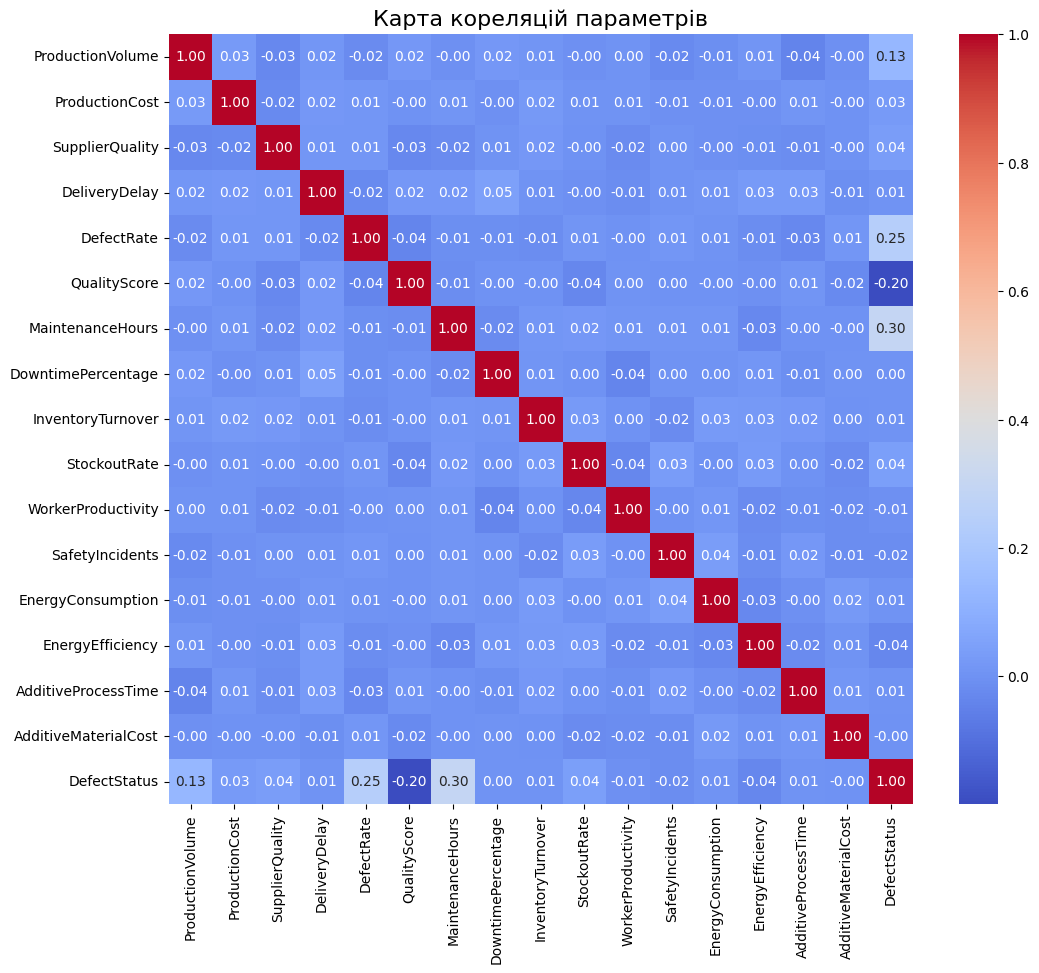

In [90]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Карта кореляцій параметрів', fontsize=16)
plt.show()

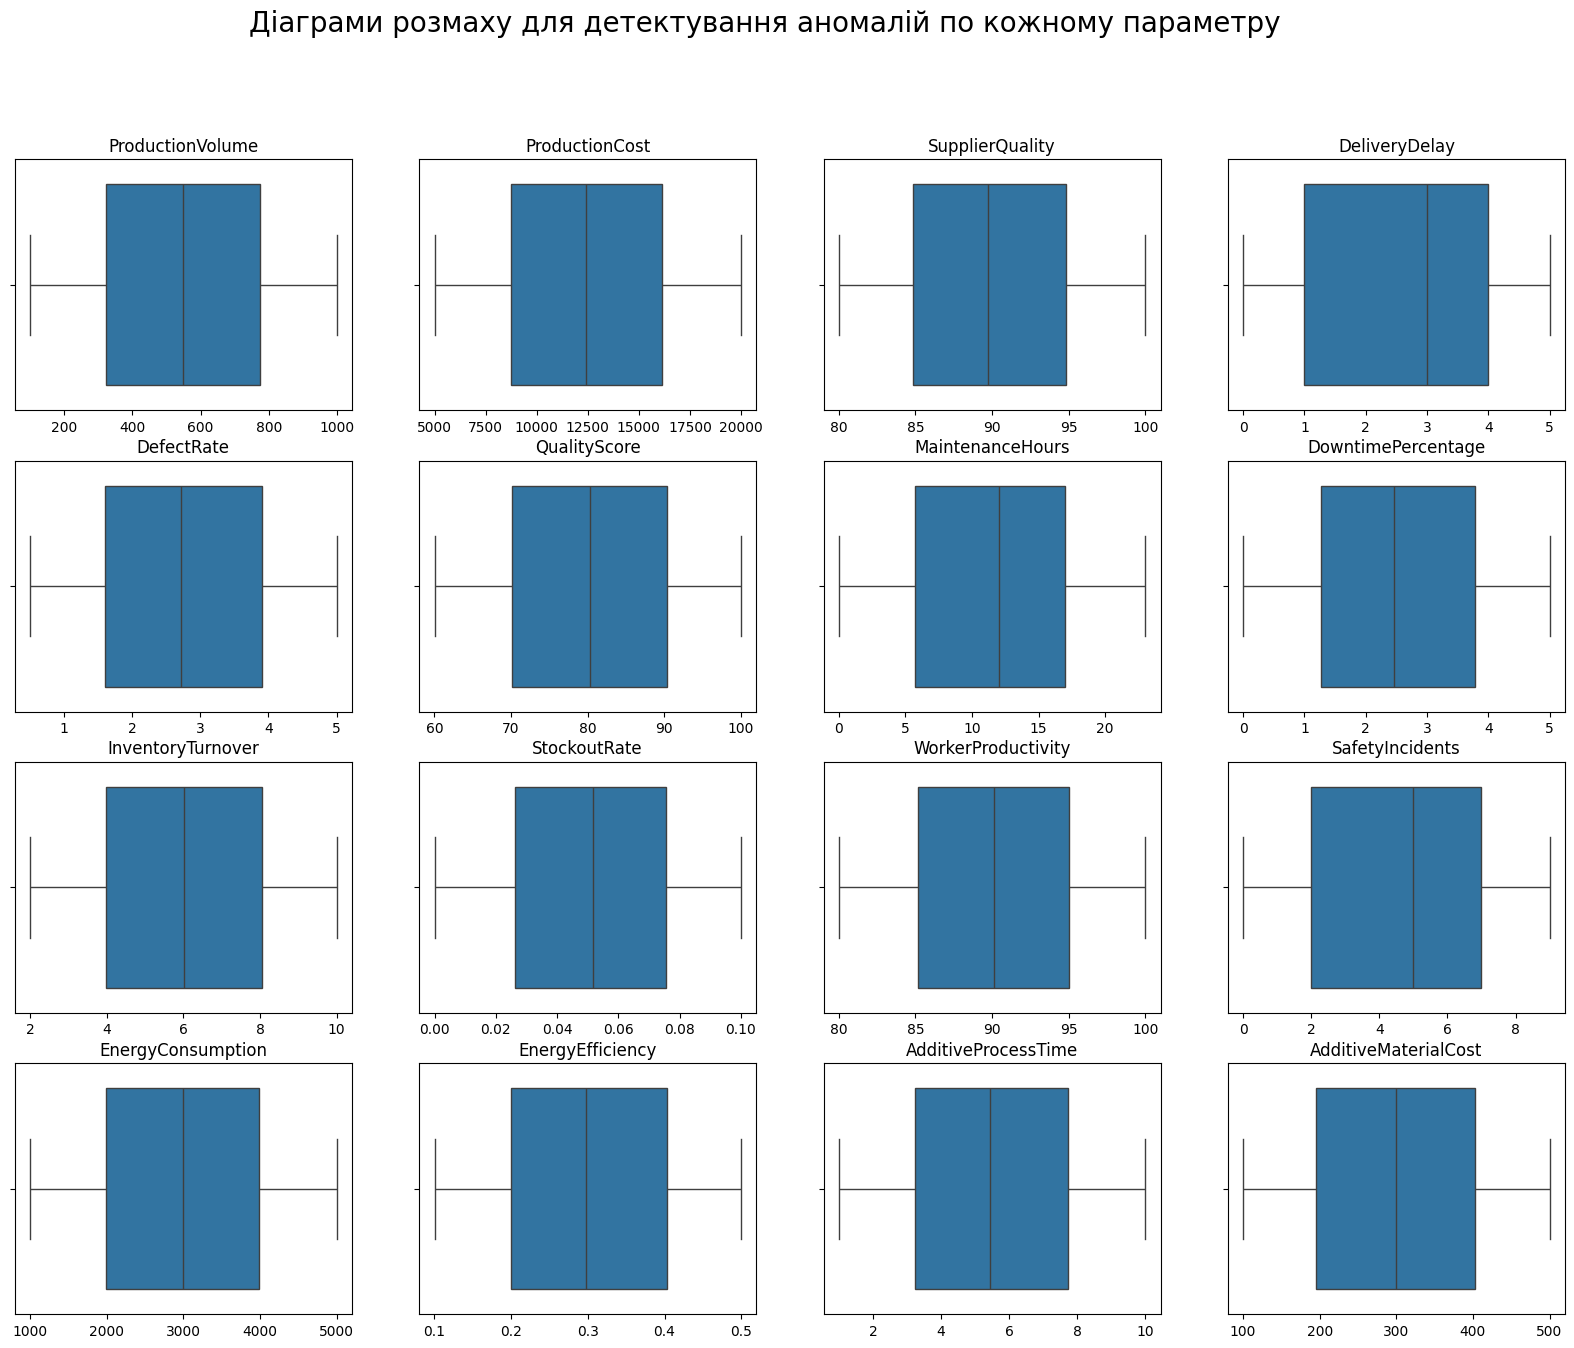

In [91]:
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
fig.suptitle('Діаграми розмаху для детектування аномалій по кожному параметру', fontsize=20)

axes = axes.flatten()

for i, feature in enumerate(input_variables):
    sns.boxplot(x=feature, data=df, ax=axes[i])
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel('')

plt.show()

# MLP

In [92]:
class MLP:
    def __init__(self, layer_dims, class_weights=None):
        """
        Fully connected Multi-Layer Perceptron (MLP)

        layer_dims: list of layer sizes, e.g. [input_dim, hidden1, ..., output_dim]
        """
        self.layer_dims = layer_dims
        self.weights = []
        self.biases = []
        self.class_weights = class_weights

        # Initialize weights and biases
        for i in range(1, len(layer_dims)):
            w = np.random.randn(layer_dims[i-1], layer_dims[i]) * np.sqrt(2 / layer_dims[i-1])
            b = np.zeros((1, layer_dims[i]))
            self.weights.append(w)
            self.biases.append(b)

    # ===== Activation functions =====
    def _relu(self, Z):
        return np.maximum(0, Z)

    def _relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def _softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    # ===== Forward pass =====
    def forward(self, X):
        """
        Forward propagation.
        Returns:
            A_last: output probabilities (after softmax)
            cache: dictionary with intermediate values for backprop
        """
        cache = {'A0': X}
        A = X
        num_layers = len(self.weights)

        # Hidden layers
        for l in range(num_layers - 1):
            Z = A.dot(self.weights[l]) + self.biases[l]
            A = self._relu(Z)
            cache[f'Z{l}'] = Z
            cache[f'A{l+1}'] = A

        # Output layer
        Z_last = A.dot(self.weights[-1]) + self.biases[-1]
        A_last = self._softmax(Z_last)
        cache[f'Z{num_layers-1}'] = Z_last
        cache[f'A{num_layers}'] = A_last

        return A_last, cache

    # ===== Loss function =====
    def _compute_loss(self, Y_onehot, A_last):
        """
        Computes cross-entropy loss for one-hot encoded labels.
        """
        m = Y_onehot.shape[0]
        ce = -np.sum(Y_onehot * np.log(A_last + 1e-9), axis=1)

        if self.class_weights is not None:
            weights = np.sum(Y_onehot * np.array([self.class_weights.get(i, 1.0)
                                                  for i in range(Y_onehot.shape[1])]), axis=1)
            ce *= weights

        loss = np.mean(ce)
        return loss

    # ===== Backward pass =====
    def backward(self, Y_onehot, cache):
        """
        Computes gradients of weights and biases.
        Returns: dictionary grads with keys 'dW0', 'db0', etc.
        """
        grads = {}
        m = Y_onehot.shape[0]
        num_layers = len(self.weights)

        # Gradient for output layer
        A_last = cache[f'A{num_layers}']
        dZ = A_last - Y_onehot
        if self.class_weights is not None:
          weights = np.sum(Y_onehot * np.array([self.class_weights.get(i, 1.0)
                                                for i in range(Y_onehot.shape[1])]), axis=1, keepdims=True)
          dZ *= weights

        A_prev = cache[f'A{num_layers-1}']
        grads[f'dW{num_layers-1}'] = (A_prev.T @ dZ) / m
        grads[f'db{num_layers-1}'] = np.sum(dZ, axis=0, keepdims=True) / m

        # Gradients for hidden layers
        for l in reversed(range(num_layers - 1)):
            dA = dZ @ self.weights[l+1].T if l+1 < num_layers else dZ
            Z = cache[f'Z{l}']
            dZ = dA * self._relu_derivative(Z)
            A_prev = cache[f'A{l}']
            grads[f'dW{l}'] = (A_prev.T @ dZ) / m
            grads[f'db{l}'] = np.sum(dZ, axis=0, keepdims=True) / m

        return grads

    # ===== Update parameters =====
    def update_params(self, grads, learning_rate):
        """Updates weights and biases using gradient descent"""
        for l in range(len(self.weights)):
            self.weights[l] -= learning_rate * grads[f'dW{l}']
            self.biases[l] -= learning_rate * grads[f'db{l}']

    # ===== Training =====
    def fit(self, X, y, X_val=None, y_val=None, epochs=1000, learning_rate=0.01, verbose=True):
        """
        Trains the MLP using gradient descent.
        X: input data (m x n)
        y: class labels (m,)
        """
        encoder = OneHotEncoder(sparse_output=False)
        Y_onehot = encoder.fit_transform(y.reshape(-1, 1))

        if X_val is not None and y_val is not None:
          Y_val_onehot = encoder.transform(y_val.reshape(-1, 1))


        history = {'train_loss': [], 'val_loss': []}
        for epoch in range(epochs):
            A_last, cache = self.forward(X)
            loss = self._compute_loss(Y_onehot, A_last)
            history['train_loss'].append(loss)

            if X_val is not None and y_val is not None:
              A_val, _ = self.forward(X_val)
              val_loss = self._compute_loss(Y_val_onehot, A_val)
              history['val_loss'].append(val_loss)

            grads = self.backward(Y_onehot, cache)
            self.update_params(grads, learning_rate)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

        return history

    # ===== Prediction =====
    def predict(self, X):
        """
        Returns predicted class labels for each example
        """
        A_last, _ = self.forward(X)
        return np.argmax(A_last, axis=1)


## Testing

In [93]:
X = df.drop('DefectStatus', axis=1)
y = df['DefectStatus'].values

In [94]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [96]:
def cross_val_analysis(X, y, mlp_class, layer_dims, class_weights=None,
                       n_splits=5, epochs=500, learning_rate=0.01):
    """
    Performs stratified K-Fold CV on an MLP and plots:
      1. Loss dynamics (train & val) for each fold
      2. Classification report
      3. Confusion matrix

    Parameters:
    - X, y: data
    - mlp_class: class of your MLP
    - layer_dims: list of layer sizes
    - class_weights: dict {class: weight} for imbalanced classes
    - n_splits: number of folds
    - epochs, learning_rate: training hyperparameters
    """

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fig, axes = plt.subplots(n_splits, 3, figsize=(18, 4*n_splits))

    if n_splits == 1:
        axes = np.expand_dims(axes, 0)  # handle 1 fold case

    fold_num = 0
    for train_index, val_index in kf.split(X, y):
        fold_num += 1
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Initialize MLP
        mlp = mlp_class(layer_dims=layer_dims, class_weights=class_weights)
        train_history = []

        # Fit MLP and track train/val loss
        encoder = OneHotEncoder(sparse_output=False)
        Y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
        Y_val_onehot = encoder.transform(y_val.reshape(-1, 1))

        for epoch in range(epochs):
            A_train, cache_train = mlp.forward(X_train)
            loss_train = mlp._compute_loss(Y_train_onehot, A_train)

            A_val, cache_val = mlp.forward(X_val)
            loss_val = mlp._compute_loss(Y_val_onehot, A_val)

            grads = mlp.backward(Y_train_onehot, cache_train)
            mlp.update_params(grads, learning_rate)

            train_history.append((loss_train, loss_val))

        train_history = np.array(train_history)
        axes[fold_num-1, 0].plot(train_history[:,0], label='Train Loss')
        axes[fold_num-1, 0].plot(train_history[:,1], label='Val Loss')
        axes[fold_num-1, 0].set_title(f'Fold {fold_num} Loss Dynamics')
        axes[fold_num-1, 0].set_xlabel('Epochs')
        axes[fold_num-1, 0].set_ylabel('Loss')
        axes[fold_num-1, 0].legend()

        # Predictions
        y_pred = mlp.predict(X_val)

        # Classification report as table
        report_dict = classification_report(y_val, y_pred, output_dict=True, zero_division=0)
        report_df = pd.DataFrame(report_dict).transpose()
        axes[fold_num-1, 1].axis('off')
        axes[fold_num-1, 1].table(cellText=np.round(report_df.values, 3),
                                  rowLabels=report_df.index,
                                  colLabels=report_df.columns,
                                  loc='center')
        axes[fold_num-1, 1].set_title(f'Fold {fold_num} Classification Report')

        # Confusion matrix
        cm = confusion_matrix(y_val, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[fold_num-1, 2])
        axes[fold_num-1, 2].set_title(f'Fold {fold_num} Confusion Matrix')
        axes[fold_num-1, 2].set_xlabel('Predicted')
        axes[fold_num-1, 2].set_ylabel('True')

    plt.tight_layout()
    plt.show()


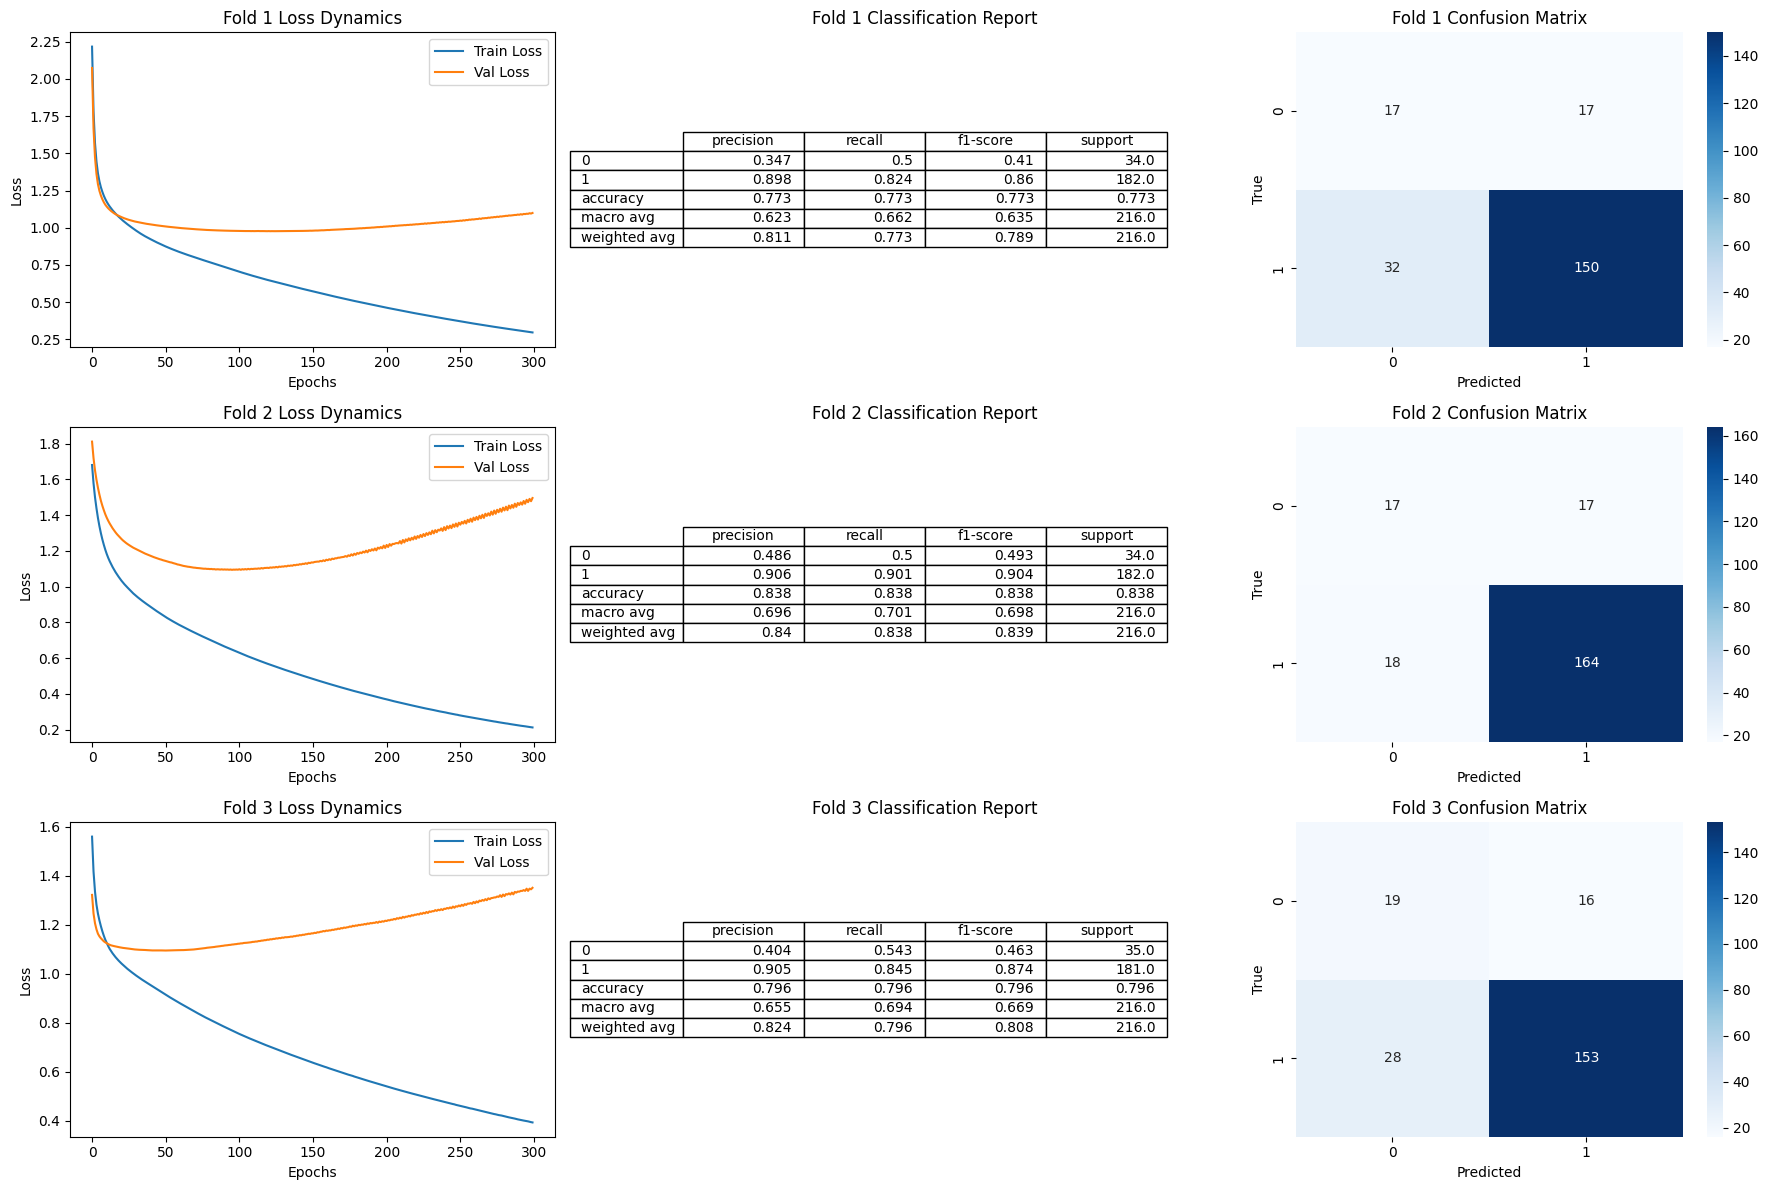

In [97]:
cross_val_analysis(X_test, y_test, mlp_class=MLP, layer_dims=[X.shape[1], 128, 64, 32, 16, 2],
                   class_weights={0:5, 1:1}, n_splits=3, epochs=300, learning_rate=0.01)

In [98]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")

print("Path to dataset files:", path)

100%|██████████| 48.6k/48.6k [00:00<00:00, 19.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/breast-cancer-dataset/versions/1
